In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv("../data/processed/nba_stats_clean.csv")

stats_cols = [
    'per','ts_percent','x3p_ar','f_tr','orb_percent','drb_percent','trb_percent',
    'ast_percent'
]
stats_cols_2 = [
    'stl_percent','blk_percent','tov_percent','usg_percent',
    'ows','dws','ws','bpm','vorp'
]
print("\nNombre de joueurs par poste :")
display(df['pos'].value_counts())


Nombre de joueurs par poste :


pos
SG    1522
PG    1347
PF    1330
SF    1279
C     1230
Name: count, dtype: int64

In [2]:
desc_stats = df.groupby('pos')[stats_cols].agg(['mean','std'])
print("\nStatistiques descriptives par poste :")
display(desc_stats)


Statistiques descriptives par poste :


per           ts_percent              x3p_ar                f_tr  \
          mean       std       mean       std      mean       std      mean   
pos                                                                           
C    17.163902  4.173080   0.583774  0.059214  0.108728  0.166417  0.354090   
PF   14.697218  4.257132   0.553490  0.049198  0.295417  0.228040  0.266577   
PG   14.565850  4.381320   0.533841  0.047558  0.371572  0.154212  0.238667   
SF   12.802346  3.885634   0.546206  0.047185  0.414418  0.175121  0.234017   
SG   12.918528  3.566568   0.545825  0.045686  0.446045  0.162000  0.215312   

              orb_percent           drb_percent           trb_percent  \
          std        mean       std        mean       std        mean   
pos                                                                     
C    0.152391   10.244390  3.284423   22.424797  5.231479   16.330976   
PF   0.122526    6.602782  3.213143   18.167744  4.620127   12.379850   
PG   0.104921    2.287231  1.145759   10.593022  3.187314    6.434224   
SF   0.103385    3.742220  1.845457   13.836278  3.507836    8.781861   
SG   0.093802    2.487582  1.363938   10.860512  2.846040    6.669514   

              ast_percent            
          std        mean       std  
pos                                  
C    3.512182    9.812927  5.822958  
PF   3.300726   10.261203  5.964717  
PG   1.914482   26.667335  8.460583  
SF   2.214948   10.870758  5.672775  
SG   1.773938   13.916820  6.483102

In [3]:
desc_stats = df.groupby('pos')[stats_cols_2].agg(['mean','std'])
print("\nStatistiques descriptives par poste :")
display(desc_stats)


Statistiques descriptives par poste :


stl_percent           blk_percent           tov_percent            \
           mean       std        mean       std        mean       std   
pos                                                                     
C      1.312358  0.517954    3.717724  1.725262   13.882846  3.951379   
PF     1.408947  0.503937    2.041654  1.278723   11.779699  3.467025   
PG     1.850557  0.588603    0.758946  0.554878   15.035709  3.935561   
SF     1.612197  0.548557    1.321267  0.774385   11.265911  2.933100   
SG     1.619382  0.577099    0.936005  0.615249   11.324967  3.031998   

    usg_percent                 ows                 dws                  ws  \
           mean       std      mean       std      mean       std      mean   
pos                                                                           
C     18.246748  5.227002  2.147480  1.932942  1.856829  1.150214  4.004146   
PF    18.843835  5.063145  1.690752  1.867386  1.602932  1.015989  3.294662   
PG    20.928359  5.335035  1.727097  2.280116  1.275056  0.920617  3.002376   
SF    18.126036  4.887509  1.373729  1.793004  1.396638  0.984383  2.770446   
SG    19.743167  5.050441  1.322865  1.665784  1.205191  0.855976  2.527004   

                    bpm                vorp            
          std      mean       std      mean       std  
pos                                                    
C    2.798295  0.268211  2.693229  0.968293  1.343878  
PF   2.581314 -0.361128  2.567523  0.778571  1.264482  
PG   2.886073 -0.160728  2.993645  0.940015  1.544624  
SF   2.517526 -0.786630  2.544539  0.645895  1.289301  
SG   2.202410 -0.927595  2.304479  0.564060  1.092520

On cherche a identifier les statistiques permettant de classer les joueurs par poste en clusters, par conséquent on n'utilisera que les statistiques avec une moyenne relativement élévée et surtout avec un écart-type élevé afin d'identifier les valeurs discriminantes et ainsi classer les différents types de joueurs par poste.

In [ ]:
On ne peut utiliser les statistiques directement liées aux victoires, car sinon les clusters seraient classés par niveau et non pas style de jeu comme recherché.
    On retire donc toutes les statistiques liées au winshare (WS, OWS, DWS)

Il en résulte pour le poste de meneur(PG):
    "ast_percent",
    "usg_percent",
    "tov_percent",
    "ts_percent",
    "x3p_ar",
    "stl_percent",
    "bpm",
    "vorp"

Pour le poste d'arrière(SG):
    "usg_percent",
    "ts_percent",
    "x3p_ar",
    "f_tr",
    "ast_percent",
    "stl_percent",
    "tov_percent",
    "bpm"

Pour le poste d'ailier(SF):
    "usg_percent",
    "ast_percent",
    "x3p_ar",
    "ts_percent",
    "trb_percent",
    "stl_percent",
    "blk_percent",
    "bpm"

Pour le poste d'ailier fort(PF):
    "trb_percent",
    "orb_percent",
    "blk_percent",
    "x3p_ar",
    "ts_percent",
    "usg_percent",
    "bpm",
    "dws"   

Pour le poste de pivot(C):
    "orb_percent",
    "trb_percent",
    "blk_percent",
    "ast_percent",
    "x3p_ar",
    "ts_percent",
    "usg_percent",
    "bpm",
    "vorp" 

In [ ]:
On visualise par le biais de boites à moustaches les statistiques qui  permettent de différencier les joueurs. 

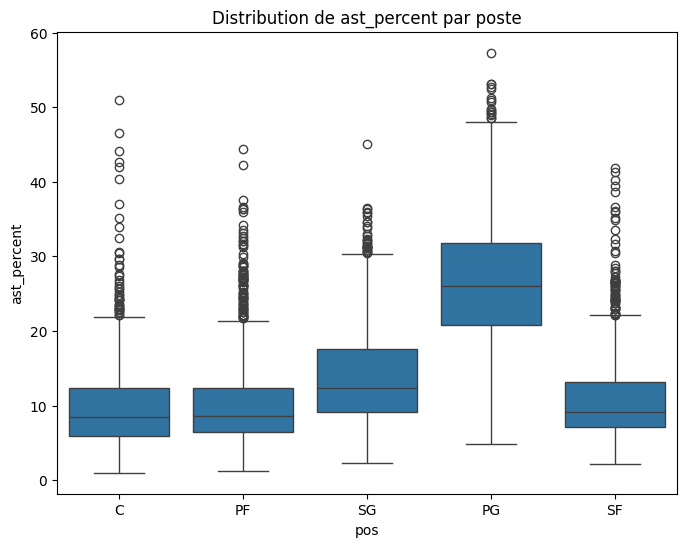

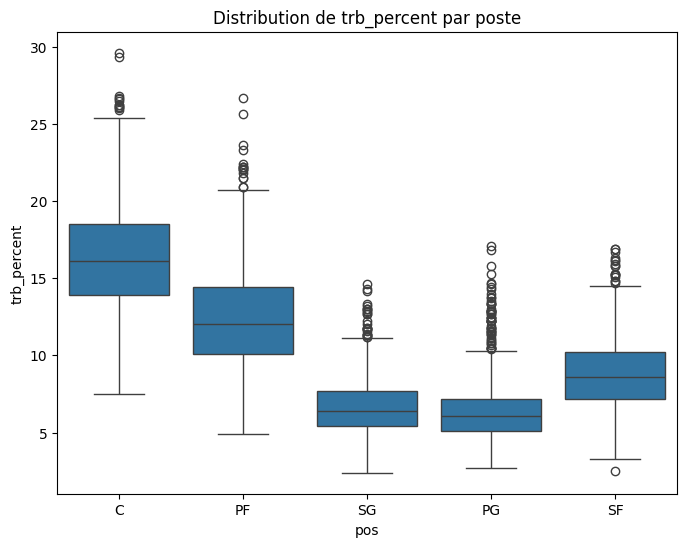

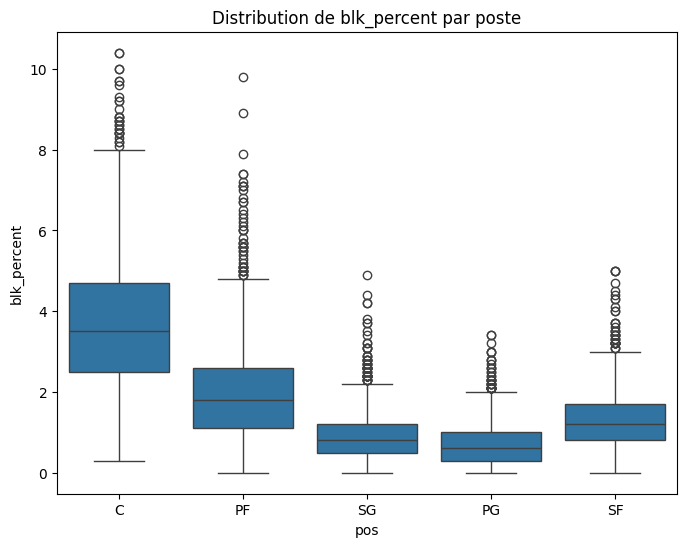

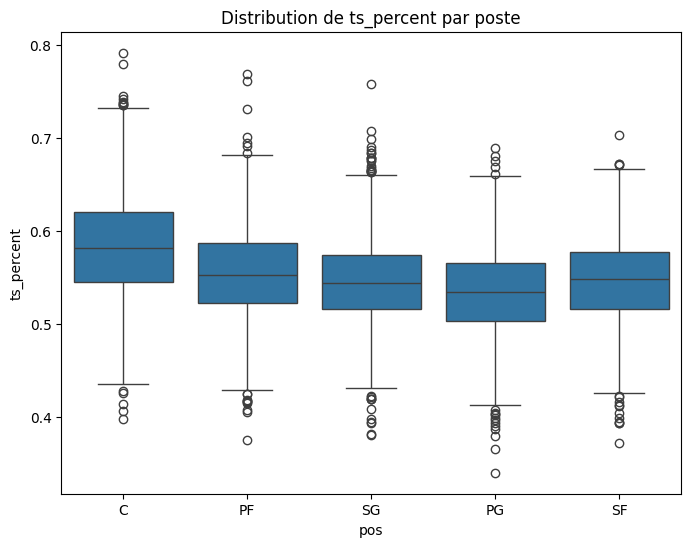

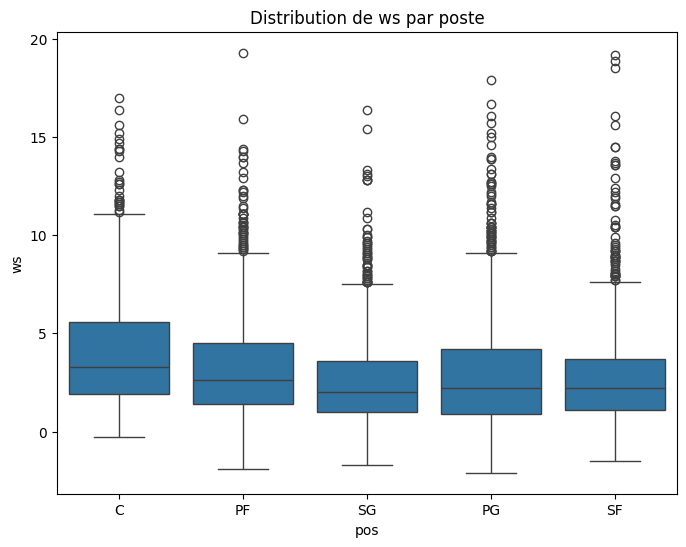

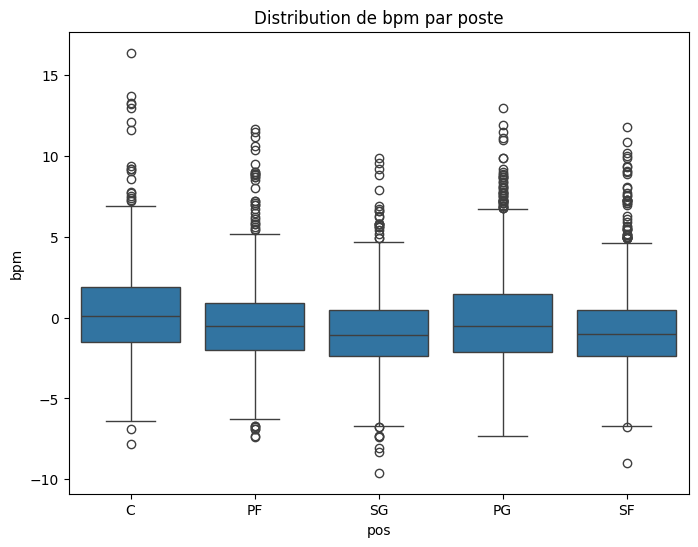

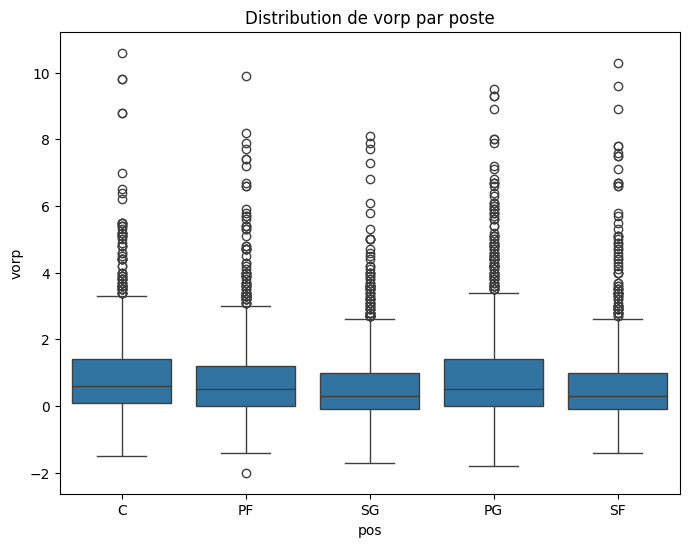

In [3]:
def boxplot_stat(stat):
    plt.figure(figsize=(8,6))
    sns.boxplot(x='pos', y=stat, data=df)
    plt.title(f"Distribution de {stat} par poste")
    plt.show()

stats_to_plot = ['ast_percent','trb_percent','blk_percent','ts_percent','ws','bpm','vorp']
for stat in stats_to_plot:
    boxplot_stat(stat)

In [ ]:
Par ces tableaux de corrélation (heatmap), on peut visualiser l'influence des statistiques les unes sur les autres . 
Quelques corrélations interessantes: on constate que le taux d'assist est inversement corrélé au taux de tir à 3 points(-0,31 pour les PG) ce qui est logique, si le joueur prend plus de tir à 3 points, il sera moins amené a tenter une passe dans la raquette ou autour.
On constate également une très forte corrélation chez les postes forts (PF, C) entre le tir à 3 points est le rebond (moins de -0,5) il faudra donc voir par la suite si les équipes privilégiant les tirs à 3 points aux prises de rebonds en tirent bénéfices. 

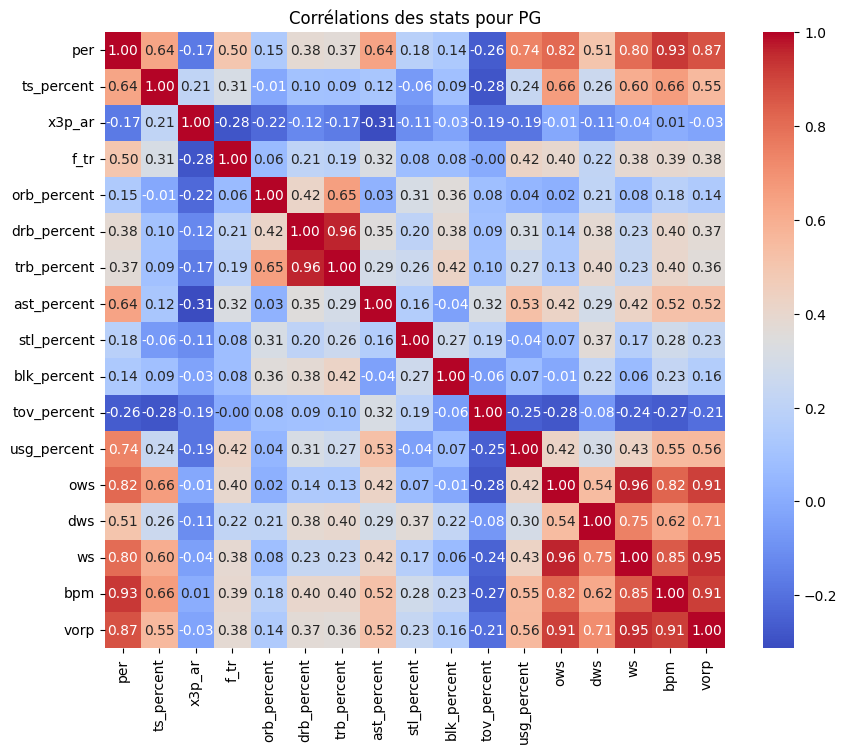

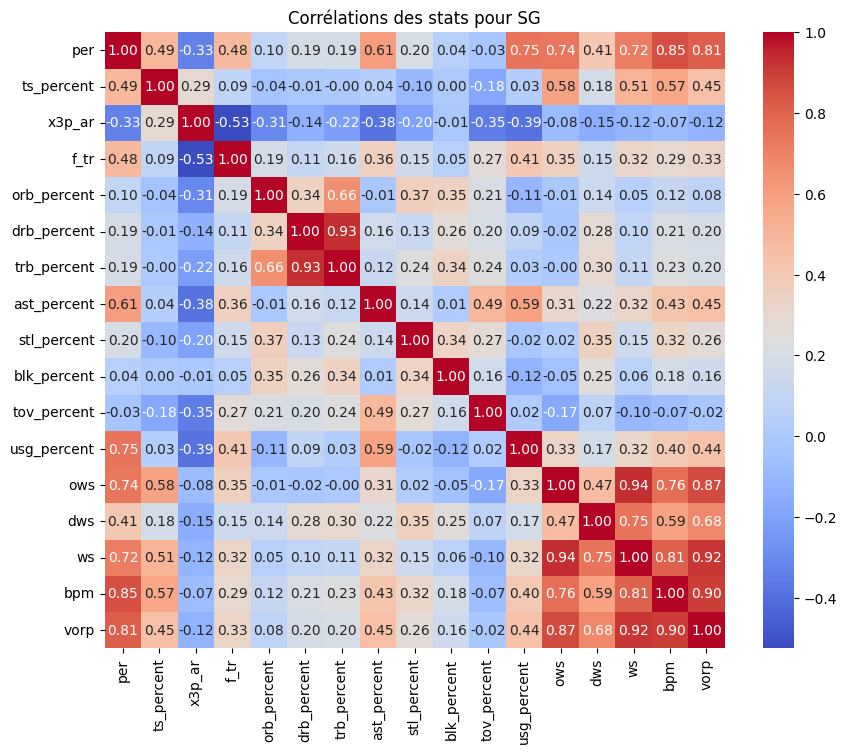

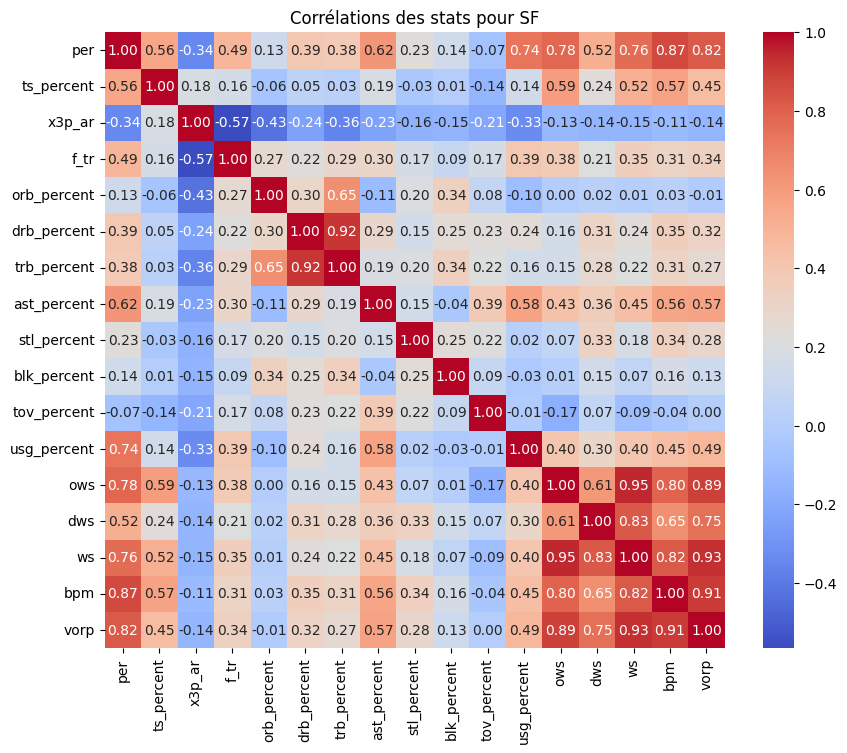

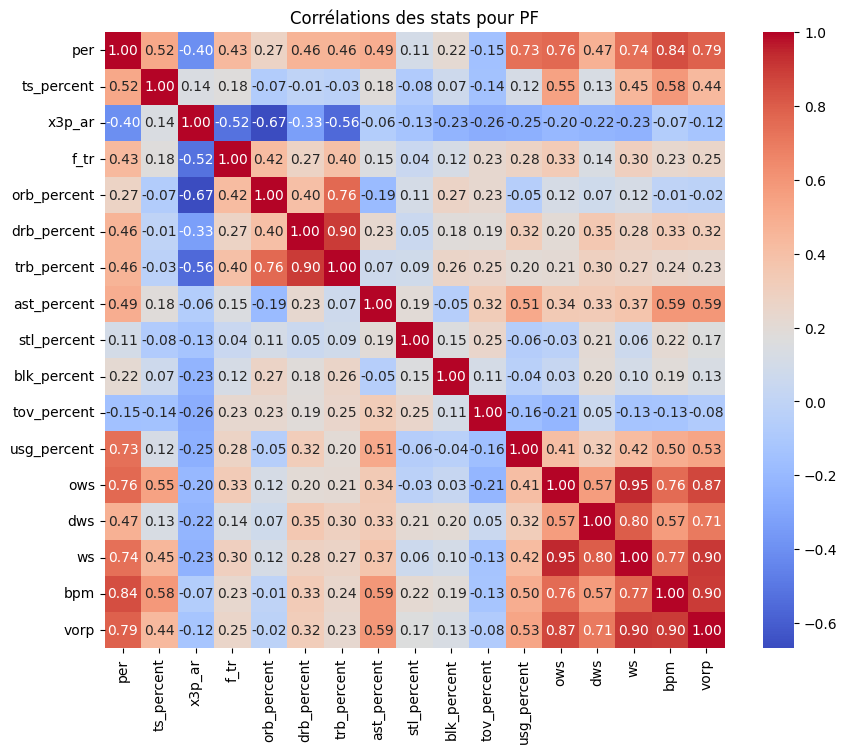

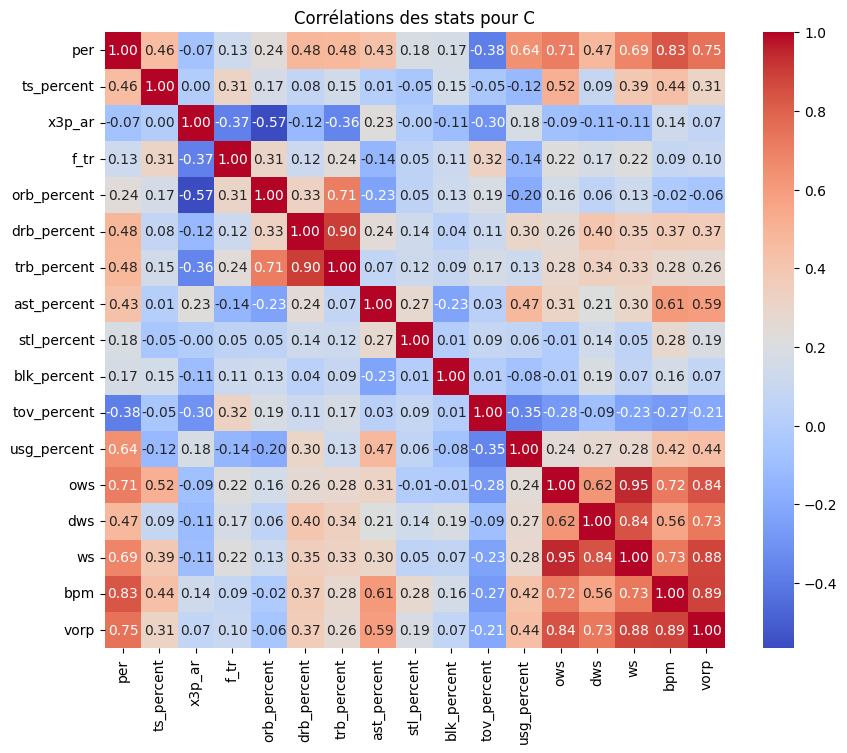

In [4]:
def correlation_heatmap(poste):
    plt.figure(figsize=(10,8))
    sns.heatmap(df[df['pos']==poste][stats_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title(f"Corrélations des stats pour {poste}")
    plt.show()

postes = ['PG','SG','SF','PF','C']
for poste in postes:
    correlation_heatmap(poste)

In [4]:
summary_stats = {
    'PG': ['per', 'ts_percent', 'ast_percent', 'usg_percent', 'tov_percent', 'stl_percent'],
    'SG': ['per', 'ts_percent', 'x3p_ar', 'f_tr', 'usg_percent', 'tov_percent', 'stl_percent'],
    'SF': ['per', 'ts_percent', 'x3p_ar', 'ast_percent', 'usg_percent', 'tov_percent', 'stl_percent', 'trb_percent'],
    'PF': ['per', 'trb_percent', 'orb_percent', 'drb_percent', 'blk_percent'],
    'C':  ['per', 'trb_percent', 'orb_percent', 'drb_percent', 'blk_percent']
}


print("\n Statistiques pertinentes par poste :")
for poste, stats in summary_stats.items():
    print(f"{poste} : {', '.join(stats)}")


 Statistiques pertinentes par poste :
PG : per, ts_percent, ast_percent, usg_percent, tov_percent, stl_percent
SG : per, ts_percent, x3p_ar, f_tr, usg_percent, tov_percent, stl_percent
SF : per, ts_percent, x3p_ar, ast_percent, usg_percent, tov_percent, stl_percent, trb_percent
PF : per, trb_percent, orb_percent, drb_percent, blk_percent
C : per, trb_percent, orb_percent, drb_percent, blk_percent
